 # SAE Validation: Order by Scale Paper

 This script validates the key predictions from the "Order by Scale" paper about
 graded latent activations in Sparse Autoencoders trained on SEP token activations.

 **Key Predictions to Validate:**
 1. SAE decoder directions align with (E_di + P_di) vectors
 2. SAE latent activations correlate with attention probabilities (α_s→d1, α_s→d2)
 3. Same features active for (a,b) and (b,a) but with different magnitudes (graded, not binary)
 4. Relative magnitude encodes sequence order

In [ ]:
import os

import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from tqdm.auto import tqdm
from scipy import stats

# Use BatchTopKSAE from dictionary_learning library
from dictionary_learning.trainers.batch_top_k import BatchTopKSAE

# Import project utilities (add parent to path for imports)
import sys
sys.path.insert(0, '..')
from model_scripts.model_utils import configure_runtime, load_model, parse_model_name_safe
from model_scripts.data import get_dataset

# Set Device
device = "cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu"
print(f"Using device: {device}")
torch.set_grad_enabled(False) # don't need gradients - analysis only

/Users/Subspace_Explorer/Documents/Programming/list-comp/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: mps


torch.autograd.grad_mode.set_grad_enabled(mode=False)

 ## 1. Configuration & Model Loading

In [ ]:
# --- Configuration (Must match training) ---
MODEL_NAME = '2layer_100dig_64d'
MODEL_CFG = parse_model_name_safe(MODEL_NAME)
SAVE_FOLDER = '../results/sae_models'

SAVE_NAME = 'sae_d100_k4_50ksteps_2layer_100dig_64d.pt'
SAE_PATH = os.path.join(SAVE_FOLDER, SAVE_NAME)

# Architecture (will be overridden by checkpoint config)
D_MODEL = MODEL_CFG.d_model

# Model Config (derived from model name)
N_LAYERS = MODEL_CFG.n_layers
N_HEADS = 1
LIST_LEN = 2
N_DIGITS = MODEL_CFG.n_digits
SEP_TOKEN_INDEX = 2  # Position of SEP in [d1, d2, SEP, o1, o2]

# Output Config
SAVE_DIR = None  # Set to "../results/sae_results/" to enable saving plots

Parsed model config: 2 layers, 100 digits, 64 d_model


In [ ]:
# --- Load Models ---
MODEL_PATH = "../models/" + MODEL_NAME + ".pt"

# Setup Runtime (required by model_utils)
configure_runtime(
    list_len=LIST_LEN,
    seq_len=2 * LIST_LEN + 1,  # [d1, d2, SEP, o1, o2] = 5
    vocab=N_DIGITS + 2,  # digits + MASK + SEP
    device=device
)

# Load base transformer model (with required kwargs)
try:
    model = load_model(
        MODEL_PATH,
        n_layers=N_LAYERS,
        n_heads=N_HEADS,
        d_model=D_MODEL,
        ln=False,
        use_bias=False,
        use_wv=False,
        use_wo=False
    )
    print(f"✓ Loaded base model from {MODEL_PATH}")
except Exception as e:
    print(f"✗ Error loading model: {e}")
    raise

# Load SAE using library's BatchTopKSAE
sae_checkpoint = torch.load(SAE_PATH, map_location=device, weights_only=False)

# Extract config from checkpoint
sae_cfg = sae_checkpoint.get("cfg", {})
D_SAE = sae_cfg.get("dict_size", sae_cfg.get("d_sae", 256))
TOP_K = sae_cfg.get("k", 4)

# Library's BatchTopKSAE uses (activation_dim, dict_size, k) constructor
sae = BatchTopKSAE(
    activation_dim=D_MODEL,
    dict_size=D_SAE,
    k=TOP_K
).to(device)

# Load state dict (handles both old and new formats)
old_state_dict = sae_checkpoint["state_dict"]
if "W_enc" in old_state_dict:
    # Legacy format conversion (for old sae.pt)
    new_state_dict = {
        "encoder.weight": old_state_dict["W_enc"].T,
        "encoder.bias": old_state_dict["b_enc"],
        "decoder.weight": old_state_dict["W_dec"].T,
        "b_dec": old_state_dict["b_dec"],
    }
    sae.load_state_dict(new_state_dict, strict=False)
    print("  (Converted legacy checkpoint format)")
else:
    sae.load_state_dict(old_state_dict)
    print(f"  (Threshold: {sae.threshold.item():.4f})")

# Load the mean for centering (critical for SAE)
act_mean = sae_checkpoint["act_mean"].to(device)

print(f"✓ Loaded SAE from {SAE_PATH}")
print(f"  - Latent dim: {D_SAE}")
print(f"  - TopK: {TOP_K}")

Loading model from ../models/2layer_100dig_64d.pt
Moving model to device:  mps
✓ Loaded base model from ../models/2layer_100dig_64d.pt
  (Threshold: 0.1891)
✓ Loaded SAE from ../results/sae_models/sae_d100_k4_50ksteps_2layer_100dig_64d.pt
  - Latent dim: 100
  - TopK: 4


 ## 2. Collect Activations and Attention Patterns

 From the paper, the SEP token residual after layer 1 is:
 ```
 r_s^L1 = α_s→d1 (E_d1 + P_d1) + α_s→d2 (E_d2 + P_d2) + E_s + P_s
 ```

 We need to collect:
 - SEP token activations (to run through SAE)
 - Attention patterns α_s→d1 and α_s→d2

In [ ]:
# Generate ALL (d1, d2) pairs for complete analysis
val_ds, _ = get_dataset(
    list_len=LIST_LEN,
    n_digits=N_DIGITS,
    train_split=1.0,  # Get all data
    no_dupes=False    # Include d1 == d2 cases
)
val_dl = DataLoader(val_ds, batch_size=2048, shuffle=False)

# Storage
all_d1 = []
all_d2 = []
all_sep_acts = []       # SEP token activations
all_sae_acts = []       # SAE latent activations
all_alpha_d1 = []       # Attention: SEP -> d1
all_alpha_d2 = []       # Attention: SEP -> d2

print("Collecting activations and attention patterns...")

layer_idx = 0  # Layer 1 (0-indexed) - where composition happens
hook_name_resid = f"blocks.{layer_idx}.hook_resid_post"
hook_name_attn = f"blocks.{layer_idx}.attn.hook_pattern"

with torch.no_grad():
    for inputs, targets in tqdm(val_dl):
        inputs = inputs.to(device)
        
        # Extract d1, d2 values
        d1 = inputs[:, 0]
        d2 = inputs[:, 1]
        
        # Run model and cache activations
        _, cache = model.run_with_cache(
            inputs, 
            stop_at_layer=layer_idx + 1,
            names_filter=[hook_name_resid, hook_name_attn]
        )
        
        # Get SEP token activations: [batch, d_model]
        sep_acts = cache[hook_name_resid][:, SEP_TOKEN_INDEX, :]
        
        # Get attention pattern: [batch, n_heads, seq, seq]
        # We want attention FROM SEP (query) TO d1 and d2 (keys)
        attn_pattern = cache[hook_name_attn][:, 0, :, :]  # [batch, seq, seq] (single head)
        alpha_d1 = attn_pattern[:, SEP_TOKEN_INDEX, 0]  # SEP attending to d1
        alpha_d2 = attn_pattern[:, SEP_TOKEN_INDEX, 1]  # SEP attending to d2
        
        # Run SAE encoding (with mean centering)
        sep_acts_centered = sep_acts - act_mean
        sae_z = sae.encode(sep_acts_centered, use_threshold=True)
        
        # Store
        all_d1.append(d1.cpu())
        all_d2.append(d2.cpu())
        all_sep_acts.append(sep_acts.cpu())
        all_sae_acts.append(sae_z.cpu())
        all_alpha_d1.append(alpha_d1.cpu())
        all_alpha_d2.append(alpha_d2.cpu())

# Concatenate
d1_all = torch.cat(all_d1)
d2_all = torch.cat(all_d2)
sep_acts_all = torch.cat(all_sep_acts)
sae_acts_all = torch.cat(all_sae_acts)
alpha_d1_all = torch.cat(all_alpha_d1)
alpha_d2_all = torch.cat(all_alpha_d2)

n_samples = len(d1_all)
print(f"\n✓ Collected {n_samples} samples")
print(f"  - SEP activations shape: {sep_acts_all.shape}")
print(f"  - SAE activations shape: {sae_acts_all.shape}")

100%|██████████| 5/5 [00:00<00:00, 19.50it/s]


✓ Collected 10000 samples
  - SEP activations shape: torch.Size([10000, 64])
  - SAE activations shape: torch.Size([10000, 100])


 ## 3. Basic SAE Metrics

In [ ]:
print("=" * 60)
print("SAE METRICS")
print("=" * 60)

# L0 Sparsity
l0 = (sae_acts_all > 0).float().sum(dim=1).mean()
print(f"Average L0 (active features per sample): {l0:.2f}")

# Dead features
dead_features = (sae_acts_all.sum(dim=0) == 0).sum().item()
print(f"Dead features: {dead_features} / {D_SAE} ({100*dead_features/D_SAE:.1f}%)")

# Feature firing rates
firing_rate = (sae_acts_all > 0).float().mean(dim=0)
print(f"Firing rate range: [{firing_rate[firing_rate > 0].min():.4f}, {firing_rate.max():.4f}]")

SAE METRICS
Average L0 (active features per sample): 3.89
Dead features: 0 / 100 (0.0%)
Firing rate range: [0.0199, 0.4818]


 ## 3b. Max Activating Examples (Sanity Check)

 Before running correlations, verify that features actually encode what we think.
 For each top feature, show the inputs that maximize its activation.

 **Expected patterns:**
 - Position-specific features (E_d + P_d): Activate for one digit at one position
 - Order features (like 189): Activate based on attention ratio, not specific digits

In [ ]:
print("\n" + "=" * 60)
print("Max Activating Examples")
print("=" * 60)

# Analyze top features by firing rate
top_k_to_analyze = 10
top_feat_indices = torch.argsort(firing_rate, descending=True)[:top_k_to_analyze]

print(f"\nFor each of the top {top_k_to_analyze} features (by firing rate),")
print("showing the 5 inputs with highest activation:\n")

for rank, feat_idx in enumerate(top_feat_indices):
    feat_idx = feat_idx.item()
    feat_acts = sae_acts_all[:, feat_idx]
    
    if feat_acts.sum() == 0:
        continue
    
    # Get top 5 activating examples
    top5_indices = torch.argsort(feat_acts, descending=True)[:5]
    top5_acts = feat_acts[top5_indices]
    top5_d1 = d1_all[top5_indices]
    top5_d2 = d2_all[top5_indices]
    top5_alpha_d1 = alpha_d1_all[top5_indices]
    top5_alpha_d2 = alpha_d2_all[top5_indices]
    
    # Compute what digit/position this feature is most selective for
    d1_selectivity = torch.zeros(N_DIGITS)
    d2_selectivity = torch.zeros(N_DIGITS)
    for digit in range(N_DIGITS):
        d1_mask = (d1_all == digit)
        d2_mask = (d2_all == digit)
        if d1_mask.sum() > 0:
            d1_selectivity[digit] = feat_acts[d1_mask].mean()
        if d2_mask.sum() > 0:
            d2_selectivity[digit] = feat_acts[d2_mask].mean()
    
    best_d1_digit = d1_selectivity.argmax().item()
    best_d2_digit = d2_selectivity.argmax().item()
    is_d1_selective = d1_selectivity.max() > d2_selectivity.max()
    
    # Classify feature type
    alpha_diff_corr = np.corrcoef(feat_acts.numpy(), (alpha_d1_all - alpha_d2_all).numpy())[0, 1]
    
    if abs(alpha_diff_corr) > 0.5:
        feat_type = f"ORDER FEATURE (r={alpha_diff_corr:.2f} with α_d1-α_d2)"
    elif is_d1_selective:
        feat_type = f"D1-Position: digit {best_d1_digit}"
    else:
        feat_type = f"D2-Position: digit {best_d2_digit}"
    
    print(f"{'─' * 55}")
    print(f"Feature {feat_idx} (rank #{rank+1}) — {feat_type}")
    print(f"{'─' * 55}")
    print(f"  {'d1':>4} {'d2':>4} {'α_d1':>6} {'α_d2':>6} {'Act':>8}")
    
    for i in range(5):
        print(f"  {top5_d1[i].item():>4} {top5_d2[i].item():>4} "
              f"{top5_alpha_d1[i].item():>6.3f} {top5_alpha_d2[i].item():>6.3f} "
              f"{top5_acts[i].item():>8.3f}")
    
    # Position invariance check (per colleague's suggestion)
    if not abs(alpha_diff_corr) > 0.5:  # Only check for digit-encoding features
        # Does this digit appear in both positions in the top activations?
        target_digit = best_d1_digit if is_d1_selective else best_d2_digit
        in_d1 = (top5_d1 == target_digit).sum().item()
        in_d2 = (top5_d2 == target_digit).sum().item()
        print(f"  → Target digit {target_digit} appears: {in_d1}x in d1, {in_d2}x in d2")
        
        if is_d1_selective and in_d1 >= 4:
            print(f"  ✓ Position-specific (D1): Consistent with paper's prediction")
        elif not is_d1_selective and in_d2 >= 4:
            print(f"  ✓ Position-specific (D2): Consistent with paper's prediction")
        else:
            print(f"  ⚠ Mixed positions: May be polysemantic")
    
    print()


Max Activating Examples

For each of the top 10 features (by firing rate),
showing the 5 inputs with highest activation:

───────────────────────────────────────────────────────
Feature 10 (rank #1) — ORDER FEATURE (r=0.80 with α_d1-α_d2)
───────────────────────────────────────────────────────
    d1   d2   α_d1   α_d2      Act
    50   70  0.848  0.152    5.928
    10   70  0.889  0.111    5.648
    49   70  0.834  0.166    5.532
    46   70  0.831  0.169    5.476
    24   70  0.895  0.105    5.409

───────────────────────────────────────────────────────
Feature 84 (rank #2) — ORDER FEATURE (r=-0.72 with α_d1-α_d2)
───────────────────────────────────────────────────────
    d1   d2   α_d1   α_d2      Act
    77    1  0.393  0.607    4.156
    77   29  0.172  0.828    4.022
    77   95  0.189  0.811    3.998
    77   39  0.326  0.674    3.976
    70    1  0.292  0.708    3.959

───────────────────────────────────────────────────────
Feature 25 (rank #3) — D1-Position: digit 53
───────

 ## 4. Validation 1: Decoder-Embedding Alignment

 **Prediction:** SAE learns decoder directions corresponding to D1 = E_d1 + P_d1 and D2 = E_d2 + P_d2

 We compute cosine similarity between SAE decoder vectors and the (token + position) embeddings.

In [ ]:
print("\n" + "=" * 60)
print("VALIDATION 1: Decoder-Embedding Alignment")
print("=" * 60)

# Get embedding matrices from base model
w_e = model.embed.W_E.detach()  # [vocab, d_model] - token embeddings
w_pos = model.pos_embed.W_pos.detach()  # [seq_len, d_model] - position embeddings

# Compute D1 and D2 directions for all possible digit values
# D_i = E[d_i] + P[position_i]
# Position 0 = d1, Position 1 = d2
D1_directions = w_e[:N_DIGITS] + w_pos[0]  # [100, d_model]
D2_directions = w_e[:N_DIGITS] + w_pos[1]  # [100, d_model]

# Normalize decoder vectors for cosine similarity
# Library stores decoder.weight as [d_model, d_sae], so transpose to get [d_sae, d_model]
W_dec = sae.decoder.weight.T.detach()  # [d_sae, d_model]
W_dec_norm = F.normalize(W_dec, dim=1)  # [d_sae, d_model]
D1_norm = F.normalize(D1_directions, dim=1)  # [100, d_model]
D2_norm = F.normalize(D2_directions, dim=1)  # [100, d_model]

# Compute max cosine similarity for each SAE feature
# For each decoder direction, find best matching D1 or D2 direction
cos_D1 = W_dec_norm @ D1_norm.T  # [d_sae, 100]
cos_D2 = W_dec_norm @ D2_norm.T  # [d_sae, 100]

max_cos_D1 = cos_D1.abs().max(dim=1).values  # [d_sae]
max_cos_D2 = cos_D2.abs().max(dim=1).values  # [d_sae]

# Get best match overall
best_match = torch.maximum(max_cos_D1, max_cos_D2)

# Analyze top features by firing rate
top_k_features = 300
top_indices = torch.argsort(firing_rate, descending=True)[:top_k_features]
top_alignments = best_match[top_indices]

print(f"\nAlignment of top {top_k_features} features (by firing rate) with D = E + P directions:")
print(f"  Mean cosine similarity: {top_alignments.mean():.4f}")
print(f"  Max cosine similarity:  {top_alignments.max():.4f}")
print(f"  Features with alignment > 0.8: {(top_alignments > 0.8).sum().item()}")
print(f"  Features with alignment > 0.5: {(top_alignments > 0.5).sum().item()}")


VALIDATION 1: Decoder-Embedding Alignment

Alignment of top 300 features (by firing rate) with D = E + P directions:
  Mean cosine similarity: 0.8282
  Max cosine similarity:  0.9652
  Features with alignment > 0.8: 85
  Features with alignment > 0.5: 99


 ## 5. Validation 2: Activation-Attention Correlation

 **Prediction:** SAE latent activations should equal attention probabilities (α_s→d1, α_s→d2)

 For features aligned with D1, their activation should correlate with α_s→d1, and similarly for D2.

In [ ]:
print("\n" + "=" * 60)
print("VALIDATION 2: Activation-Attention Correlation")
print("=" * 60)

# For each top feature, determine if it's more aligned with D1 or D2 pattern
# Then compute correlation with corresponding attention weight

# Features more aligned with D1 pattern (via position embedding)
is_D1_aligned = max_cos_D1 > max_cos_D2

correlations_with_alpha = []
feature_info = []

for feat_idx in top_indices[:20]:  # Analyze top 20 features
    feat_acts = sae_acts_all[:, feat_idx].numpy()
    
    if feat_acts.sum() == 0:  # Skip dead features
        continue
    
    # Correlate with alpha_d1 and alpha_d2
    corr_d1, p_d1 = stats.pearsonr(feat_acts, alpha_d1_all.numpy())
    corr_d2, p_d2 = stats.pearsonr(feat_acts, alpha_d2_all.numpy())
    
    # Expected: aligned features correlate with their respective alpha
    aligned_with = "D1" if is_D1_aligned[feat_idx] else "D2"
    expected_corr = corr_d1 if aligned_with == "D1" else corr_d2
    
    correlations_with_alpha.append({
        'feature': feat_idx.item(),
        'aligned_with': aligned_with,
        'corr_alpha_d1': corr_d1,
        'corr_alpha_d2': corr_d2,
        'expected_corr': expected_corr,
        'alignment': best_match[feat_idx].item()
    })

corr_df = pd.DataFrame(correlations_with_alpha)
print("\nTop features correlation with attention patterns:")
print(corr_df.to_string(index=False))

avg_expected_corr = corr_df['expected_corr'].mean()
print(f"\nAverage correlation with expected alpha: {avg_expected_corr:.4f}")


VALIDATION 2: Activation-Attention Correlation

Top features correlation with attention patterns:
 feature aligned_with  corr_alpha_d1  corr_alpha_d2  expected_corr  alignment
      10           D1       0.803147      -0.803147       0.803147   0.873189
      84           D1      -0.716852       0.716852      -0.716852   0.871345
      25           D2      -0.003742       0.003742       0.003742   0.880350
      19           D2       0.000509      -0.000509      -0.000509   0.533816
      36           D2      -0.003875       0.003875       0.003875   0.882504
      28           D2       0.000345      -0.000345      -0.000345   0.792099
      13           D2       0.001487      -0.001487      -0.001487   0.821894
       9           D2      -0.001057       0.001057       0.001057   0.845379
      14           D2      -0.001624       0.001624       0.001624   0.562487
      82           D2      -0.000379       0.000379       0.000379   0.880880
      21           D2      -0.000947       

 This value is surprisingly low!

 ### Validation 2 Reasoning

 The Order by Scale paper predicts that the SEP token residual stream is:
 ```
 r_SEP = α_{s→d1}(E_d1 + P_d1) + α_{s→d2}(E_d2 + P_d2) + constant
 ```

 If SAE features align with (E_di + P_di) directions, then their activations should
 be proportional to the attention weights α. However, the above test correlates
 feature activations with attention *across all samples*, which mixes different digits.

 A more precise test: for features that encode a *specific* digit (e.g., d1=50),
 their activation should correlate with α_d1 specifically when d1=50 is present.

In [ ]:
# --- Validation 2b: Digit-Specific Activation-Attention Correlation ---
print("\n" + "=" * 60)
print("VALIDATION 2b: Digit-Specific Activation-Attention Correlation")
print("=" * 60)

# For each feature, find which digit it's most selective for
# Then check if activation correlates with attention FOR THAT DIGIT ONLY

digit_specific_results = []

for feat_idx in top_indices[:50]:  # Analyze top 50 features
    feat_acts = sae_acts_all[:, feat_idx].numpy()
    
    if feat_acts.sum() == 0:
        continue
    
    # Find which digit value this feature is most selective for
    # by looking at mean activation for each d1 and d2 value
    d1_selectivity = np.zeros(N_DIGITS)
    d2_selectivity = np.zeros(N_DIGITS)
    
    for digit in range(N_DIGITS):
        d1_mask = (d1_all.numpy() == digit)
        d2_mask = (d2_all.numpy() == digit)
        
        if d1_mask.sum() > 0:
            d1_selectivity[digit] = feat_acts[d1_mask].mean()
        if d2_mask.sum() > 0:
            d2_selectivity[digit] = feat_acts[d2_mask].mean()
    
    # Determine if feature is more d1-selective or d2-selective
    best_d1_digit = d1_selectivity.argmax()
    best_d2_digit = d2_selectivity.argmax()
    
    is_d1_feature = d1_selectivity.max() > d2_selectivity.max()
    best_digit = best_d1_digit if is_d1_feature else best_d2_digit
    
    # Now correlate activation with attention for samples containing this digit
    if is_d1_feature:
        mask = (d1_all.numpy() == best_digit)
        alpha_relevant = alpha_d1_all.numpy()[mask]
        position = "D1"
    else:
        mask = (d2_all.numpy() == best_digit)
        alpha_relevant = alpha_d2_all.numpy()[mask]
        position = "D2"
    
    acts_relevant = feat_acts[mask]
    
    # Only compute correlation if we have enough samples and variance
    if len(acts_relevant) >= 10 and acts_relevant.std() > 1e-6:
        corr, p_val = stats.pearsonr(acts_relevant, alpha_relevant)
        
        digit_specific_results.append({
            'feature': feat_idx.item(),
            'position': position,
            'best_digit': best_digit,
            'n_samples': len(acts_relevant),
            'correlation': corr,
            'p_value': p_val,
            'mean_activation': acts_relevant.mean(),
        })

digit_df = pd.DataFrame(digit_specific_results)
if len(digit_df) > 0:
    # Sort by absolute correlation
    digit_df = digit_df.sort_values('correlation', key=abs, ascending=False)
    
    print("\nDigit-specific feature correlations with attention:")
    print(digit_df.head(20).to_string(index=False))
    
    # Summary stats
    strong_corr = (digit_df['correlation'].abs() > 0.3).sum()
    mean_abs_corr = digit_df['correlation'].abs().mean()
    
    print(f"\nFeatures with |correlation| > 0.3: {strong_corr}/{len(digit_df)}")
    print(f"Mean |correlation|: {mean_abs_corr:.4f}")


VALIDATION 2b: Digit-Specific Activation-Attention Correlation

Digit-specific feature correlations with attention:
 feature position  best_digit  n_samples  correlation      p_value  mean_activation
      10       D1          10        100     0.963796 4.588644e-58         3.227910
      32       D1          34        100     0.873657 1.997245e-32         4.192126
      83       D1           2        100     0.867856 1.557975e-31         3.824659
      70       D1           8        100     0.866043 2.902170e-31         3.772308
      92       D1          51        100     0.861512 1.321598e-30         3.887778
      20       D1           5        100     0.861414 1.364912e-30         3.710272
      25       D1          53        100     0.860724 1.710929e-30         3.806282
      43       D1          78        100     0.857874 4.295652e-30         3.744782
      85       D1          21        100     0.856190 7.332469e-30         3.538116
      27       D1          66        100   

 ## 6. Validation 3: Graded Activations (Same Features, Different Magnitudes)

 **Prediction:** The same features are active for (a,b) and (b,a), but with different magnitudes.
 This contradicts the binary view of SAE features.

In [ ]:
print("\n" + "=" * 60)
print("VALIDATION 3a: Graded Activations for Swapped Inputs")
print("=" * 60)

# For pairs (a, b) and (b, a), compare which features fire and their magnitudes
# We need to find matching pairs where d1=a, d2=b and d1=b, d2=a

# Create index for fast lookup
pair_to_idx = {}
for i in range(n_samples):
    pair_to_idx[(d1_all[i].item(), d2_all[i].item())] = i

# Find all swappable pairs (where a != b)
swapped_comparisons = []
for i in range(n_samples):
    a, b = d1_all[i].item(), d2_all[i].item()
    if a >= b:  # Only process each pair once, skip a==b
        continue
    
    if (b, a) in pair_to_idx:
        j = pair_to_idx[(b, a)]
        
        acts_ab = sae_acts_all[i]  # Features for (a, b)
        acts_ba = sae_acts_all[j]  # Features for (b, a)
        
        # Find features active in BOTH
        both_active = (acts_ab > 0) & (acts_ba > 0)
        n_both = both_active.sum().item()
        
        # Among features active in both, what's the magnitude difference?
        if n_both > 0:
            ratio = acts_ab[both_active] / acts_ba[both_active]
            
            swapped_comparisons.append({
                'a': a, 'b': b,
                'n_shared_features': n_both,
                'n_ab_only': ((acts_ab > 0) & (acts_ba == 0)).sum().item(),
                'n_ba_only': ((acts_ab == 0) & (acts_ba > 0)).sum().item(),
                'mean_ratio': ratio.mean().item(),
                'min_ratio': ratio.min().item(),
                'max_ratio': ratio.max().item(),
            })

swap_df = pd.DataFrame(swapped_comparisons)

print(f"\nAnalyzed {len(swap_df)} swapped pairs (a,b) vs (b,a)")
print(f"\nShared features (active in BOTH swapped inputs):")
print(f"  Mean count: {swap_df['n_shared_features'].mean():.1f}")
print(f"  Median count: {swap_df['n_shared_features'].median():.1f}")
print(f"\nMagnitude ratios (for shared features):")
print(f"  Mean ratio: {swap_df['mean_ratio'].mean():.4f}")
print(f"  Std of mean ratio: {swap_df['mean_ratio'].std():.4f}")
print(f"\nUnique features (active in only one ordering):")
print(f"  Mean (a,b) only: {swap_df['n_ab_only'].mean():.1f}")
print(f"  Mean (b,a) only: {swap_df['n_ba_only'].mean():.1f}")

# Key finding: if many features are shared but with different magnitudes, this supports graded activations
graded_evidence = swap_df['n_shared_features'].mean() > swap_df['n_ab_only'].mean()
print(f"\n✓ Graded activation evidence: {'SUPPORTED' if graded_evidence else 'NOT SUPPORTED'}")
print(f"  (More shared features than unique features indicates graded, not binary, representation)")


VALIDATION 3a: Graded Activations for Swapped Inputs

Analyzed 4950 swapped pairs (a,b) vs (b,a)

Shared features (active in BOTH swapped inputs):
  Mean count: 3.1
  Median count: 3.0

Magnitude ratios (for shared features):
  Mean ratio: 1.0312
  Std of mean ratio: 0.2099

Unique features (active in only one ordering):
  Mean (a,b) only: 0.8
  Mean (b,a) only: 0.8

✓ Graded activation evidence: SUPPORTED
  (More shared features than unique features indicates graded, not binary, representation)


 ### Concrete Example: Same Feature, Different Magnitudes

 Let's examine a specific swapped pair to see how the same feature has different
 activations that lead to different reconstructions.

In [ ]:
# --- Validation 3b: Concrete Example of Graded Activation ---
print("\n" + "=" * 60)
print("VALIDATION 3b: Concrete Example of Graded Activation")
print("=" * 60)

# Find a pair with large ratio differences (to make the effect clear)
extreme_pairs = swap_df.nlargest(5, 'max_ratio')
example = extreme_pairs.iloc[0]
a, b = int(example['a']), int(example['b'])

# Get indices for (a,b) and (b,a)
idx_ab = pair_to_idx[(a, b)]
idx_ba = pair_to_idx[(b, a)]

# Get activations
acts_ab = sae_acts_all[idx_ab]
acts_ba = sae_acts_all[idx_ba]

# Get attention patterns
alpha_ab = (alpha_d1_all[idx_ab].item(), alpha_d2_all[idx_ab].item())
alpha_ba = (alpha_d1_all[idx_ba].item(), alpha_d2_all[idx_ba].item())

print(f"\nComparing inputs (d1={a}, d2={b}) vs (d1={b}, d2={a})")
print(f"\nAttention patterns:")
print(f"  (a={a}, b={b}): α_d1={alpha_ab[0]:.3f}, α_d2={alpha_ab[1]:.3f}")
print(f"  (a={b}, b={a}): α_d1={alpha_ba[0]:.3f}, α_d2={alpha_ba[1]:.3f}")

# Find shared active features
both_active_mask = (acts_ab > 0) & (acts_ba > 0)
shared_indices = torch.where(both_active_mask)[0]

print(f"\nShared active features ({len(shared_indices)} features):")
print(f"{'Feature':>8} {'Act(a,b)':>10} {'Act(b,a)':>10} {'Ratio':>8} {'Best Digit':>12}")
print("-" * 50)

for feat_idx in shared_indices:
    act_ab = acts_ab[feat_idx].item()
    act_ba = acts_ba[feat_idx].item()
    ratio = act_ab / act_ba if act_ba > 0 else float('inf')
    
    # Find which digit this feature prefers
    feat_acts = sae_acts_all[:, feat_idx].numpy()
    d1_means = [feat_acts[d1_all.numpy() == d].mean() for d in range(N_DIGITS)]
    best_digit = np.argmax(d1_means)
    
    print(f"{feat_idx.item():>8} {act_ab:>10.3f} {act_ba:>10.3f} {ratio:>8.2f} {best_digit:>12}")


VALIDATION 3b: Concrete Example of Graded Activation

Comparing inputs (d1=10, d2=12) vs (d1=12, d2=10)

Attention patterns:
  (a=10, b=12): α_d1=0.658, α_d2=0.342
  (a=12, b=10): α_d1=0.365, α_d2=0.635

Shared active features (4 features):
 Feature   Act(a,b)   Act(b,a)    Ratio   Best Digit
--------------------------------------------------
       7      2.761      2.659     1.04           10
      10      3.414      0.227    15.03           10
      13      2.087      2.236     0.93           12
      15      1.275      1.223     1.04           62


In [ ]:
# --- Validation 3c: Feature Scaling Experiment ---
# This directly tests whether magnitude matters by SCALING a feature and observing output change

print("\n" + "=" * 60)
print("VALIDATION 3c: Feature Scaling Experiment")
print("=" * 60)
print("\nDoes scaling SAE feature magnitudes change model output?")

# Get the input tensors for both orderings
inputs_ab = val_ds.tensors[0][idx_ab:idx_ab+1].to(device)
targets_ab = val_ds.tensors[1][idx_ab:idx_ab+1].to(device)

# Get original model output
with torch.no_grad():
    orig_logits_ab = model(inputs_ab)
    orig_pred_ab = orig_logits_ab[:, -2:, :N_DIGITS].argmax(-1)

print(f"\nInput (d1={a}, d2={b}) → Original output: {orig_pred_ab[0].tolist()}  (target: {targets_ab[0, -2:].tolist()})")

# Hook for patching SAE reconstruction into model
hook_name = f"blocks.{layer_idx}.hook_resid_post"

def make_sae_patch_hook(sae_recon, sep_idx):
    """Hook that replaces SEP token residual with SAE reconstruction."""
    def hook(resid, hook):
        resid = resid.clone()
        resid[:, sep_idx, :] = sae_recon + act_mean.to(resid.device)
        return resid
    return hook

# Find the most influential feature (highest activation for this input)
z_ab = sae_acts_all[idx_ab].clone()
top_feat_idx = z_ab.argmax().item()
top_feat_val = z_ab[top_feat_idx].item()

# Find which digit this feature encodes
feat_acts = sae_acts_all[:, top_feat_idx].numpy()
d1_means = [feat_acts[d1_all.numpy() == d].mean() for d in range(N_DIGITS)]
feat_best_digit = np.argmax(d1_means)

print(f"\nScaling feature {top_feat_idx} (encodes digit {feat_best_digit})")
print(f"Original activation: {top_feat_val:.3f}")

# Scale experiments
scale_factors = [0.0, 0.5, 1.0, 1.5, 2.0]
print(f"\n{'Scale':<8} {'Feature Act':<12} {'Output o1':<12} {'Output o2':<12}")
print("-" * 45)

with torch.no_grad():
    for scale in scale_factors:
        # Modify the SAE latents
        z_scaled = z_ab.clone().to(device)
        z_scaled[top_feat_idx] = top_feat_val * scale
        
        # Decode through SAE
        recon_scaled = sae.decode(z_scaled.unsqueeze(0))
        
        # Patch into model
        patched_logits = model.run_with_hooks(
            inputs_ab,
            fwd_hooks=[(hook_name, make_sae_patch_hook(recon_scaled, SEP_TOKEN_INDEX))]
        )
        
        patched_pred = patched_logits[:, -2:, :N_DIGITS].argmax(-1)
        o1, o2 = patched_pred[0].tolist()
        
        marker = " ← original" if scale == 1.0 else ""
        print(f"{scale:<8.1f} {top_feat_val * scale:<12.3f} {o1:<12} {o2:<12}{marker}")

print("\n" + "-" * 45)
print("Scale=0 zeros out the feature; Scale=2 doubles its contribution.")


VALIDATION 3c: Feature Scaling Experiment

Does scaling SAE feature magnitudes change model output?

Input (d1=10, d2=12) → Original output: [10, 12]  (target: [10, 12])

Scaling feature 10 (encodes digit 10)
Original activation: 3.414

Scale    Feature Act  Output o1    Output o2   
---------------------------------------------
0.0      0.000        12           10          
0.5      1.707        10           10          
1.0      3.414        10           12           ← original
1.5      5.121        10           8           
2.0      6.828        10           70          

---------------------------------------------
Scale=0 zeros out the feature; Scale=2 doubles its contribution.



VALIDATION 3c-ii: Is Feature 10 an 'Order Feature'?

1. Correlation with attention patterns:
   Feature 10 vs (α_d1 - α_d2): r = 0.8031  (p = 0.00e+00)
   Feature 10 vs α_d1:          r = 0.8031
   Feature 10 vs α_d2:          r = -0.8031

   ✓ STRONG correlation with attention difference!
     → Feature 10 encodes 'd1 is more attended than d2'

2. Decoder direction alignment:
   cos(decoder_10, P_d1 - P_d2) = 0.9996

   ✓ Decoder aligns with positional difference direction!
     → Feature 10 literally encodes 'position 1 vs position 2'

3. Decoder alignment with individual position embeddings:
   cos(decoder_10, P_d1) = 0.9621
   cos(decoder_10, P_d2) = -0.6321


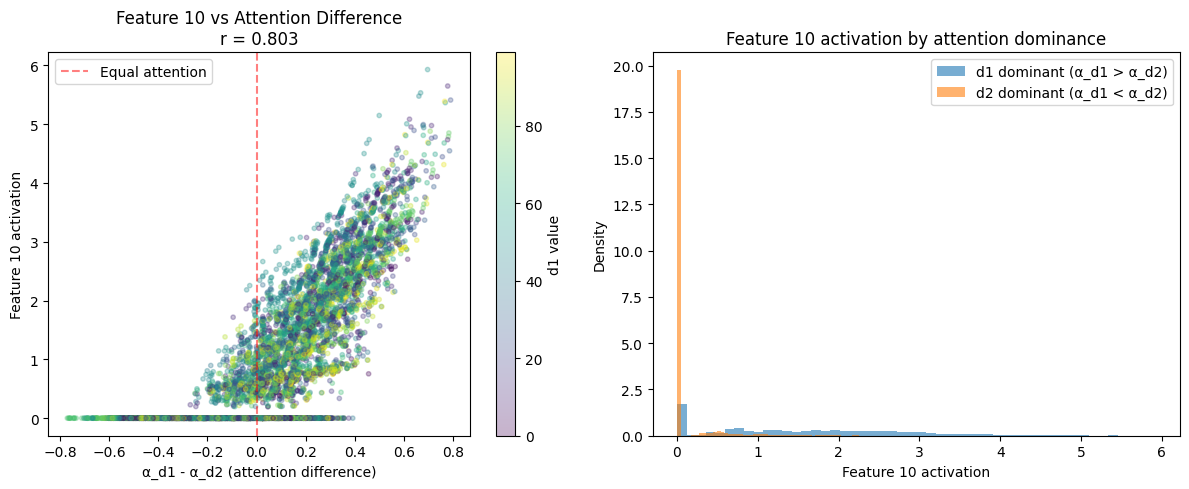

In [ ]:
# --- Validation 3c-ii: Analyze "Order Feature" ---
# Testing the hypothesis that the order feature encodes ordering, not a specific digit

ORDER_FEATURE_IDX = 10  # The feature we observed causing swaps

print("\n" + "=" * 60)
print(f"VALIDATION 3c-ii: Is Feature {ORDER_FEATURE_IDX} an 'Order Feature'?")
print("=" * 60)

# 1. Correlate order feature activation with attention DIFFERENCE (α_d1 - α_d2)
order_feat_acts = sae_acts_all[:, ORDER_FEATURE_IDX].numpy()
alpha_diff = (alpha_d1_all - alpha_d2_all).numpy()  # Positive = d1 dominant

corr_with_diff, p_val = stats.pearsonr(order_feat_acts, alpha_diff)
corr_with_d1, _ = stats.pearsonr(order_feat_acts, alpha_d1_all.numpy())
corr_with_d2, _ = stats.pearsonr(order_feat_acts, alpha_d2_all.numpy())

print(f"\n1. Correlation with attention patterns:")
print(f"   Feature {ORDER_FEATURE_IDX} vs (α_d1 - α_d2): r = {corr_with_diff:.4f}  (p = {p_val:.2e})")
print(f"   Feature {ORDER_FEATURE_IDX} vs α_d1:          r = {corr_with_d1:.4f}")
print(f"   Feature {ORDER_FEATURE_IDX} vs α_d2:          r = {corr_with_d2:.4f}")

if corr_with_diff > 0.5:
    print(f"\n   ✓ STRONG correlation with attention difference!")
    print(f"     → Feature {ORDER_FEATURE_IDX} encodes 'd1 is more attended than d2'")
elif corr_with_diff > 0.2:
    print(f"\n   ~ Moderate correlation with attention difference")
else:
    print(f"\n   ✗ Weak correlation - may encode something else")

# 2. Check decoder alignment with P_d1 - P_d2 (position embedding difference)
P_d1 = w_pos[0]  # Position embedding for d1 position
P_d2 = w_pos[1]  # Position embedding for d2 position
pos_diff = P_d1 - P_d2  # "d1 comes first" direction

# Library stores decoder.weight as [d_model, d_sae], we need [d_sae, d_model] indexing
order_dec = sae.decoder.weight[:, ORDER_FEATURE_IDX].detach()

cos_with_pos_diff = F.cosine_similarity(order_dec.unsqueeze(0), pos_diff.unsqueeze(0)).item()

print(f"\n2. Decoder direction alignment:")
print(f"   cos(decoder_{ORDER_FEATURE_IDX}, P_d1 - P_d2) = {cos_with_pos_diff:.4f}")

if abs(cos_with_pos_diff) > 0.5:
    print(f"\n   ✓ Decoder aligns with positional difference direction!")
    print(f"     → Feature {ORDER_FEATURE_IDX} literally encodes 'position 1 vs position 2'")
elif abs(cos_with_pos_diff) > 0.2:
    print(f"\n   ~ Partial alignment with positional difference")
else:
    print(f"\n   ✗ Weak alignment - may capture different structure")

# 3. Also check alignment with just P_d1 and P_d2 separately
cos_with_P_d1 = F.cosine_similarity(order_dec.unsqueeze(0), P_d1.unsqueeze(0)).item()
cos_with_P_d2 = F.cosine_similarity(order_dec.unsqueeze(0), P_d2.unsqueeze(0)).item()

print(f"\n3. Decoder alignment with individual position embeddings:")
print(f"   cos(decoder_{ORDER_FEATURE_IDX}, P_d1) = {cos_with_P_d1:.4f}")
print(f"   cos(decoder_{ORDER_FEATURE_IDX}, P_d2) = {cos_with_P_d2:.4f}")

# 4. Visualize: scatter plot of feature 189 vs attention difference
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Scatter: Order feature vs attention difference
ax1 = axes[0]
scatter = ax1.scatter(alpha_diff, order_feat_acts, alpha=0.3, s=10, c=d1_all.numpy(), cmap='viridis')
ax1.set_xlabel('α_d1 - α_d2 (attention difference)')
ax1.set_ylabel(f'Feature {ORDER_FEATURE_IDX} activation')
ax1.set_title(f'Feature {ORDER_FEATURE_IDX} vs Attention Difference\nr = {corr_with_diff:.3f}')
ax1.axvline(x=0, color='red', linestyle='--', alpha=0.5, label='Equal attention')
ax1.legend()
plt.colorbar(scatter, ax=ax1, label='d1 value')

# Histogram: Feature 189 activation when d1>d2 vs d1<d2
ax2 = axes[1]
mask_d1_dom = alpha_diff > 0
ax2.hist(order_feat_acts[mask_d1_dom], bins=50, alpha=0.6, label=f'd1 dominant (α_d1 > α_d2)', density=True)
ax2.hist(order_feat_acts[~mask_d1_dom], bins=50, alpha=0.6, label=f'd2 dominant (α_d1 < α_d2)', density=True)
ax2.set_xlabel(f'Feature {ORDER_FEATURE_IDX} activation')
ax2.set_ylabel('Density')
ax2.set_title(f'Feature {ORDER_FEATURE_IDX} activation by attention dominance')
ax2.legend()

plt.tight_layout()
plt.show()


VALIDATION 3c-iii: Feature 10 Logit Steering

Does scaling Feature 10 change logits predictably?
Prediction: Feature 10 encodes 'd1 should come first'
  → Increasing it should boost d1 logit at o1, suppress d2
  → Decreasing it should boost d2 logit at o1, suppress d1


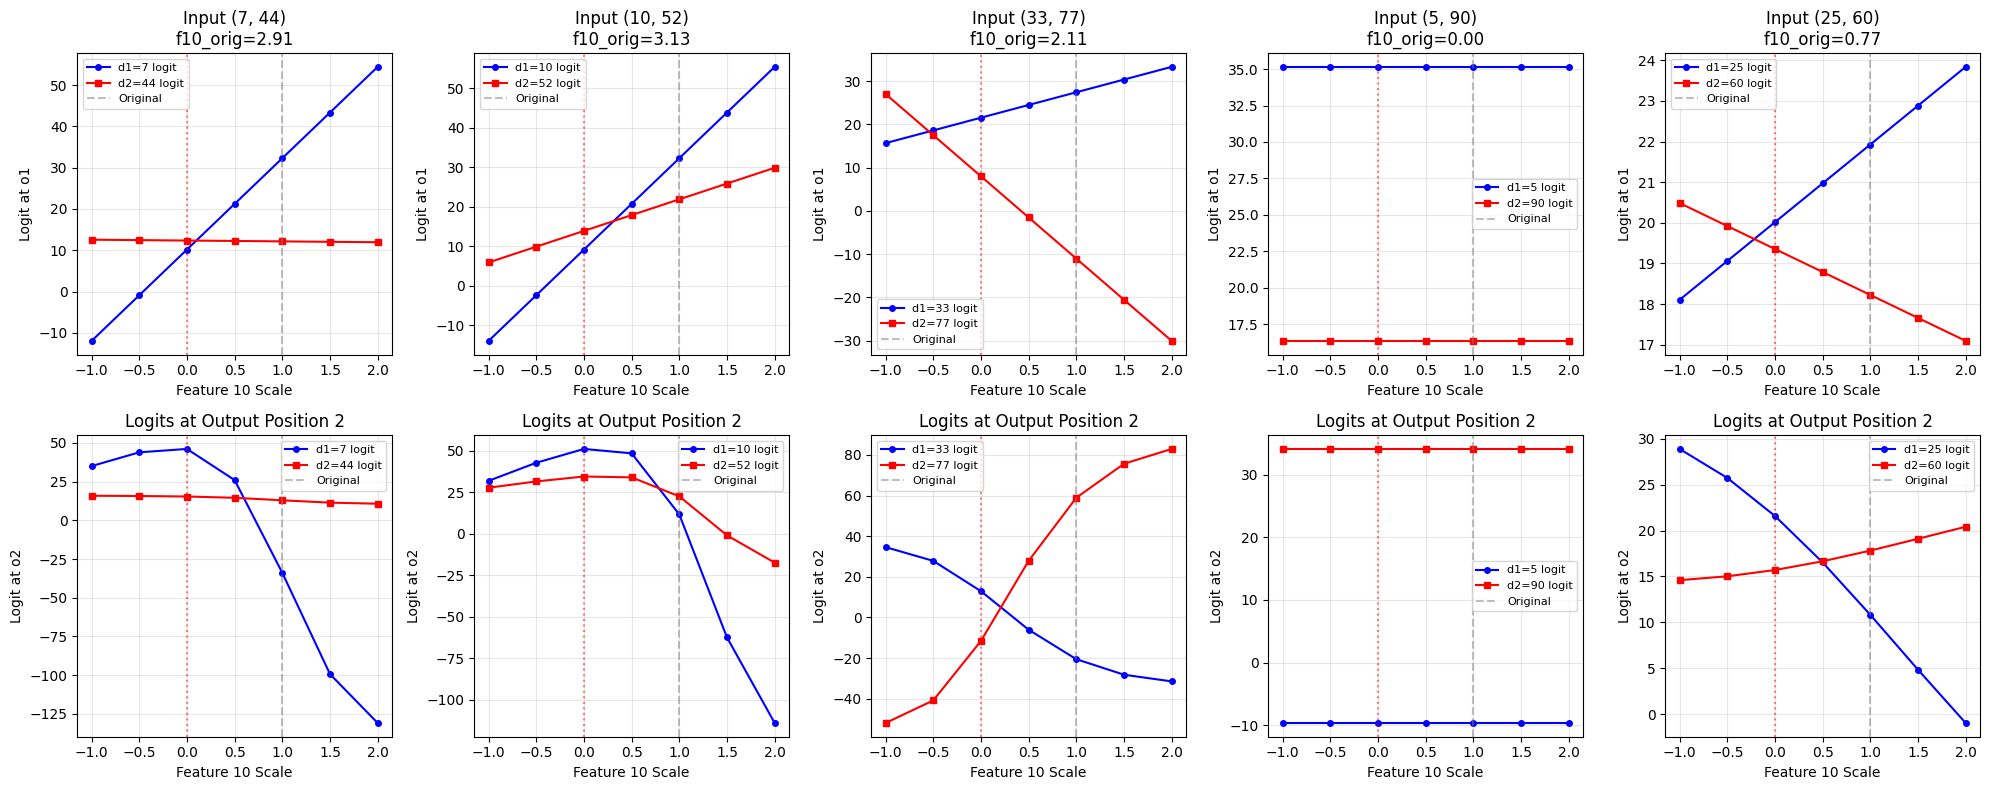


LOGIT STEERING SUMMARY

For each input, showing logit difference (d1 - d2) at o1 position:
Input        feat_orig  S=-1     S=-0.5   S=0      S=0.5    S=1.0    S=1.5    S=2.0   
-------------------------------------------------------------------------------------
( 7, 44)        2.91   -24.5   -13.3    -2.2    +9.0   +20.1   +31.3   +42.5
(10, 52)        3.13   -19.9   -12.3    -4.7    +2.8   +10.4   +18.0   +25.5
(33, 77)        2.11   -11.4    +1.1   +13.6   +26.0   +38.5   +50.9   +63.4
( 5, 90)        0.00   +18.8   +18.8   +18.8   +18.8   +18.8   +18.8   +18.8
(25, 60)        0.77    -2.4    -0.9    +0.7    +2.2    +3.7    +5.2    +6.7

----------------------------------------------------------------------
Interpretation:
  • Positive diff = d1 winning at o1 (correct order)
  • Negative diff = d2 winning at o1 (swapped order)
  • Scale=0: Feature 10 ablated → should flip to negative (swapped)
  • Scale=1: Original → should be positive (correct)
  • Scale=2: Feature 10 amplified →

In [ ]:
# --- Validation 3c-iii: Order Feature Logit Steering ---
# Does scaling the order feature change logits PREDICTABLY?
# If it encodes "d1 should come first", increasing it should:
#   - Increase logit for d1 at position o1
#   - Decrease logit for d2 at position o1 (and vice versa for o2)

print("\n" + "=" * 60)
print(f"VALIDATION 3c-iii: Feature {ORDER_FEATURE_IDX} Logit Steering")
print("=" * 60)
print(f"\nDoes scaling Feature {ORDER_FEATURE_IDX} change logits predictably?")
print(f"Prediction: Feature {ORDER_FEATURE_IDX} encodes 'd1 should come first'")
print("  → Increasing it should boost d1 logit at o1, suppress d2")
print("  → Decreasing it should boost d2 logit at o1, suppress d1")

# Select diverse test cases (different digit pairs)
np.random.seed(123)
test_pairs = [(7, 44), (10, 52), (33, 77), (5, 90), (25, 60)]

# Extended scale range: -1 to 2 to test negative scaling (reversing the feature)
scale_factors = np.array([-1.0, -0.5, 0.0, 0.5, 1.0, 1.5, 2.0])

# Storage for plotting
all_results = []

for d1_val, d2_val in test_pairs:
    # Find this pair in dataset
    mask = (d1_all == d1_val) & (d2_all == d2_val)
    if mask.sum() == 0:
        continue
    idx = torch.where(mask)[0][0].item()
    
    inputs_i = val_ds.tensors[0][idx:idx+1].to(device)
    z_orig = sae_acts_all[idx].clone().to(device)
    order_feat_orig = z_orig[ORDER_FEATURE_IDX].item()
    
    logit_d1_at_o1 = []
    logit_d2_at_o1 = []
    logit_d1_at_o2 = []
    logit_d2_at_o2 = []
    output_o1 = []
    output_o2 = []
    
    for scale in scale_factors:
        z_scaled = z_orig.clone()
        z_scaled[ORDER_FEATURE_IDX] = order_feat_orig * scale
        
        recon = sae.decode(z_scaled.unsqueeze(0))
        
        with torch.no_grad():
            patched_logits = model.run_with_hooks(
                inputs_i,
                fwd_hooks=[(hook_name, make_sae_patch_hook(recon, SEP_TOKEN_INDEX))]
            )
        
        # Get logits at o1 (position -2) and o2 (position -1)
        logits_o1 = patched_logits[0, -2, :N_DIGITS]
        logits_o2 = patched_logits[0, -1, :N_DIGITS]
        
        logit_d1_at_o1.append(logits_o1[d1_val].item())
        logit_d2_at_o1.append(logits_o1[d2_val].item())
        logit_d1_at_o2.append(logits_o2[d1_val].item())
        logit_d2_at_o2.append(logits_o2[d2_val].item())
        output_o1.append(logits_o1.argmax().item())
        output_o2.append(logits_o2.argmax().item())
    
    all_results.append({
        'd1': d1_val, 'd2': d2_val,
        'scales': scale_factors,
        'logit_d1_o1': logit_d1_at_o1,
        'logit_d2_o1': logit_d2_at_o1,
        'logit_d1_o2': logit_d1_at_o2,
        'logit_d2_o2': logit_d2_at_o2,
        'output_o1': output_o1,
        'output_o2': output_o2,
        'order_feat_orig': order_feat_orig,
    })

# Plot results
fig, axes = plt.subplots(2, len(all_results), figsize=(4*len(all_results), 8), squeeze=False)

for col, result in enumerate(all_results):
    d1, d2 = result['d1'], result['d2']
    scales = result['scales']
    
    # Top row: Logits at o1 position
    ax1 = axes[0, col]
    ax1.plot(scales, result['logit_d1_o1'], 'b-o', label=f'd1={d1} logit', markersize=4)
    ax1.plot(scales, result['logit_d2_o1'], 'r-s', label=f'd2={d2} logit', markersize=4)
    ax1.axvline(x=1.0, color='gray', linestyle='--', alpha=0.5, label='Original')
    ax1.axvline(x=0.0, color='red', linestyle=':', alpha=0.5)
    ax1.set_xlabel(f'Feature {ORDER_FEATURE_IDX} Scale')
    ax1.set_ylabel('Logit at o1')
    ax1.set_title(f'Input ({d1}, {d2})\nf{ORDER_FEATURE_IDX}_orig={result["order_feat_orig"]:.2f}')
    ax1.legend(fontsize=8)
    ax1.grid(True, alpha=0.3)
    
    # Bottom row: Logits at o2 position
    ax2 = axes[1, col]
    ax2.plot(scales, result['logit_d1_o2'], 'b-o', label=f'd1={d1} logit', markersize=4)
    ax2.plot(scales, result['logit_d2_o2'], 'r-s', label=f'd2={d2} logit', markersize=4)
    ax2.axvline(x=1.0, color='gray', linestyle='--', alpha=0.5, label='Original')
    ax2.axvline(x=0.0, color='red', linestyle=':', alpha=0.5)
    ax2.set_xlabel(f'Feature {ORDER_FEATURE_IDX} Scale')
    ax2.set_ylabel('Logit at o2')
    ax2.set_title(f'Logits at Output Position 2')
    ax2.legend(fontsize=8)
    ax2.grid(True, alpha=0.3)

plt.tight_layout()
if SAVE_DIR: plt.savefig(os.path.join(SAVE_DIR, f'feature_{ORDER_FEATURE_IDX}_logit_steering.png'), dpi=150, bbox_inches='tight')
plt.show()

# Print summary table with CORRECT indexing
# scale_factors = [-1.0, -0.5, 0.0, 0.5, 1.0, 1.5, 2.0]
#                    0     1     2    3    4    5    6
print("\n" + "=" * 85)
print("LOGIT STEERING SUMMARY")
print("=" * 85)
print("\nFor each input, showing logit difference (d1 - d2) at o1 position:")
print(f"{'Input':<12} {'feat_orig':<10} {'S=-1':<8} {'S=-0.5':<8} {'S=0':<8} {'S=0.5':<8} {'S=1.0':<8} {'S=1.5':<8} {'S=2.0':<8}")
print("-" * 85)

for result in all_results:
    d1, d2 = result['d1'], result['d2']
    order_feat = result['order_feat_orig']
    # Logit diff = logit(d1) - logit(d2) at o1 position
    diffs = [result['logit_d1_o1'][i] - result['logit_d2_o1'][i] for i in range(len(result['scales']))]
    
    # Now correctly indexed: 0=-1, 1=-0.5, 2=0, 3=0.5, 4=1.0, 5=1.5, 6=2.0
    print(f"({d1:>2}, {d2:>2})    {order_feat:>8.2f}  {diffs[0]:>+6.1f}  {diffs[1]:>+6.1f}  {diffs[2]:>+6.1f}  {diffs[3]:>+6.1f}  {diffs[4]:>+6.1f}  {diffs[5]:>+6.1f}  {diffs[6]:>+6.1f}")

print("\n" + "-" * 70)
print("Interpretation:")
print("  • Positive diff = d1 winning at o1 (correct order)")
print("  • Negative diff = d2 winning at o1 (swapped order)")
print(f"  • Scale=0: Feature {ORDER_FEATURE_IDX} ablated → should flip to negative (swapped)")
print("  • Scale=1: Original → should be positive (correct)")
print(f"  • Scale=2: Feature {ORDER_FEATURE_IDX} amplified → should be even more positive")

# Check if behavior is consistent
all_flip_at_zero = all(
    result['logit_d1_o1'][0] < result['logit_d2_o1'][0] 
    for result in all_results
)
all_correct_at_one = all(
    result['logit_d1_o1'][4] > result['logit_d2_o1'][4]  # Index 4 = S=1.0 (original)
    for result in all_results
)


VALIDATION 3d: Targeted Ablation by Digit-Encoding Feature

Step 1: Precomputing feature → digit mapping...
Mapped 100 features to digits
Found best features for 97 digits

Step 2: Running targeted ablation on 100 random pairs...
For each (d1, d2), ablate the feature encoding d1 and check if o1 changes


Targeted ablation: 100%|██████████| 100/100 [00:00<00:00, 175.02it/s]



Metric                         Rate      
---------------------------------------------
O1 changed after ablation:      100.0%
O1 became D2 after ablation:     77.0%
Full swap (o1↔o2):                0.0%


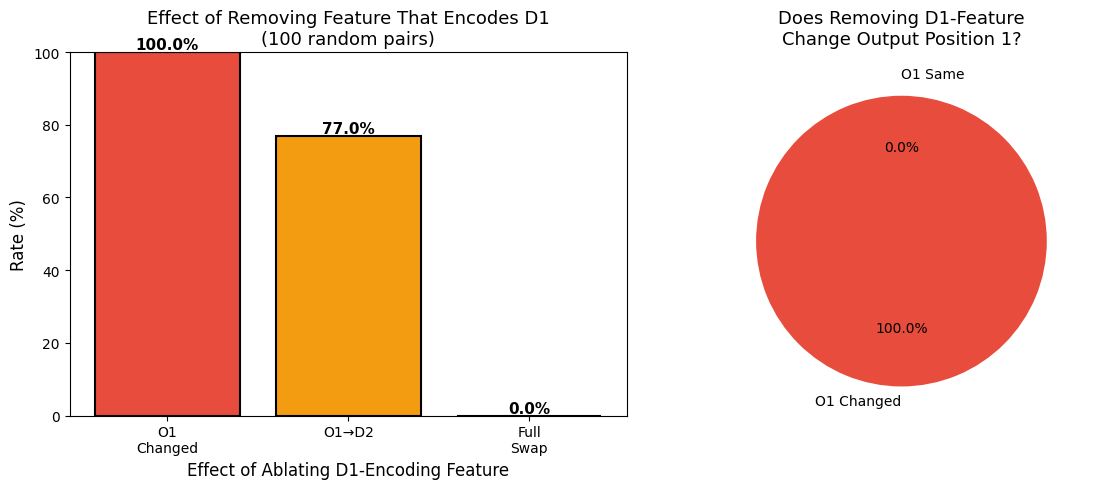

In [ ]:
# --- Validation 3d: Targeted Ablation by Digit-Encoding Feature ---
# For each sample (d1, d2):
#   1. Find the feature that encodes d1
#   2. Ablate it (scale=0) and check if o1 changes
# This tests: "removing the d1-encoding feature should affect output position 1"

print("\n" + "=" * 60)
print("VALIDATION 3d: Targeted Ablation by Digit-Encoding Feature")
print("=" * 60)

# First, precompute which digit each feature most strongly encodes
# by looking at which digit value produces max mean activation
print("\nStep 1: Precomputing feature → digit mapping...")

feature_to_digit = {}  # Maps feature_idx → best_digit

for feat_idx in range(D_SAE):
    feat_acts = sae_acts_all[:, feat_idx].numpy()
    
    if feat_acts.sum() == 0:  # Skip dead features
        continue
    
    # Mean activation for each digit value (considering both d1 and d2 positions)
    d1_selectivity = np.zeros(N_DIGITS)
    d2_selectivity = np.zeros(N_DIGITS)
    
    for digit in range(N_DIGITS):
        d1_mask = (d1_all.numpy() == digit)
        d2_mask = (d2_all.numpy() == digit)
        
        if d1_mask.sum() > 0:
            d1_selectivity[digit] = feat_acts[d1_mask].mean()
        if d2_mask.sum() > 0:
            d2_selectivity[digit] = feat_acts[d2_mask].mean()
    
    # Feature encodes the digit with highest selectivity
    best_d1 = d1_selectivity.max()
    best_d2 = d2_selectivity.max()
    
    if best_d1 > best_d2:
        feature_to_digit[feat_idx] = {'digit': d1_selectivity.argmax(), 'position': 'D1', 'strength': best_d1}
    else:
        feature_to_digit[feat_idx] = {'digit': d2_selectivity.argmax(), 'position': 'D2', 'strength': best_d2}

print(f"Mapped {len(feature_to_digit)} features to digits")

# Build reverse mapping: digit → features that encode it
digit_to_features = {}
for feat_idx, info in feature_to_digit.items():
    digit = info['digit']
    if digit not in digit_to_features:
        digit_to_features[digit] = []
    digit_to_features[digit].append((feat_idx, info['strength']))

# For each digit, keep the strongest feature
best_feature_for_digit = {}
for digit, features in digit_to_features.items():
    best_feat = max(features, key=lambda x: x[1])[0]
    best_feature_for_digit[digit] = best_feat

print(f"Found best features for {len(best_feature_for_digit)} digits")

# Step 2: Run targeted ablation
print("\nStep 2: Running targeted ablation on 100 random pairs...")
print("For each (d1, d2), ablate the feature encoding d1 and check if o1 changes")

np.random.seed(42)
valid_indices = [i for i in range(n_samples) 
                 if d1_all[i].item() != d2_all[i].item() 
                 and d1_all[i].item() in best_feature_for_digit]
sample_indices = np.random.choice(valid_indices, size=min(100, len(valid_indices)), replace=False)

ablation_results = []

with torch.no_grad():
    for idx in tqdm(sample_indices, desc="Targeted ablation"):
        d1_val = d1_all[idx].item()
        d2_val = d2_all[idx].item()
        
        # Get original output
        inputs_i = val_ds.tensors[0][idx:idx+1].to(device)
        orig_logits = model(inputs_i)
        orig_pred = orig_logits[:, -2:, :N_DIGITS].argmax(-1)
        orig_o1, orig_o2 = orig_pred[0].tolist()
        
        # Get SAE activations
        z_i = sae_acts_all[idx].clone().to(device)
        
        # Find the feature that encodes d1
        d1_feature = best_feature_for_digit.get(d1_val)
        if d1_feature is None:
            continue
        
        d1_feat_val = z_i[d1_feature].item()
        
        # Ablate: set the d1-encoding feature to 0
        z_ablated = z_i.clone()
        z_ablated[d1_feature] = 0.0
        
        # Decode and patch
        recon_ablated = sae.decode(z_ablated.unsqueeze(0))
        patched_logits = model.run_with_hooks(
            inputs_i,
            fwd_hooks=[(hook_name, make_sae_patch_hook(recon_ablated, SEP_TOKEN_INDEX))]
        )
        patched_pred = patched_logits[:, -2:, :N_DIGITS].argmax(-1)
        patched_o1, patched_o2 = patched_pred[0].tolist()
        
        # Check results
        o1_changed = (patched_o1 != orig_o1)
        o1_became_d2 = (patched_o1 == d2_val)
        swapped = (patched_o1 == orig_o2 and patched_o2 == orig_o1)
        
        ablation_results.append({
            'd1': d1_val, 'd2': d2_val,
            'orig_o1': orig_o1, 'orig_o2': orig_o2,
            'patched_o1': patched_o1, 'patched_o2': patched_o2,
            'd1_feature': d1_feature,
            'd1_feat_val': d1_feat_val,
            'o1_changed': o1_changed,
            'o1_became_d2': o1_became_d2,
            'swapped': swapped,
        })

# Analyze results
ablation_df = pd.DataFrame(ablation_results)

o1_change_rate = ablation_df['o1_changed'].mean() * 100
swap_rate = ablation_df['swapped'].mean() * 100
o1_to_d2_rate = ablation_df['o1_became_d2'].mean() * 100

print(f"\n{'Metric':<30} {'Rate':<10}")
print("-" * 45)
print(f"{'O1 changed after ablation:':<30} {o1_change_rate:>6.1f}%")
print(f"{'O1 became D2 after ablation:':<30} {o1_to_d2_rate:>6.1f}%")
print(f"{'Full swap (o1↔o2):':<30} {swap_rate:>6.1f}%")

# Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Bar chart
metrics = ['O1\nChanged', 'O1→D2', 'Full\nSwap']
rates = [o1_change_rate, o1_to_d2_rate, swap_rate]
colors = ['#e74c3c', '#f39c12', '#9b59b6']

axes[0].bar(metrics, rates, color=colors, edgecolor='black', linewidth=1.5)
axes[0].set_ylabel('Rate (%)', fontsize=12)
axes[0].set_xlabel('Effect of Ablating D1-Encoding Feature', fontsize=12)
axes[0].set_title('Effect of Removing Feature That Encodes D1\n(100 random pairs)', fontsize=13)
axes[0].set_ylim(0, 100)

for i, r in enumerate(rates):
    axes[0].annotate(f'{r:.1f}%', xy=(i, r), ha='center', va='bottom', fontsize=11, fontweight='bold')

# Pie chart
axes[1].pie([o1_change_rate, 100-o1_change_rate], 
            labels=['O1 Changed', 'O1 Same'], 
            autopct='%1.1f%%', colors=['#e74c3c', '#2ecc71'], startangle=90,
            explode=(0.05, 0))
axes[1].set_title('Does Removing D1-Feature\nChange Output Position 1?', fontsize=13)

plt.tight_layout()
if SAVE_DIR is not None:
    os.makedirs(SAVE_DIR, exist_ok=True)
    plt.savefig(os.path.join(SAVE_DIR, "targeted_ablation.png"), dpi=150)
plt.show()

 ## 7. Validation 4: Relative Magnitude Encodes Order

 **Prediction:** The order of inputs (which is larger) is encoded by the relative magnitude
 of feature activations, not by which features fire.

In [ ]:
print("\n" + "=" * 60)
print("VALIDATION 4: Relative Magnitude Encodes Order")
print("=" * 60)

# For the most frequent features, check if activation magnitude correlates with input ordering
# Specifically: does act_d1_feature - act_d2_feature correlate with d1 - d2?

# Find pairs of features: one aligned with D1 position, one with D2 position
# that often fire together

# Get feature pairs that co-occur frequently
is_D1_aligned_cpu = is_D1_aligned.cpu()
top_D1_features = top_indices[is_D1_aligned_cpu[top_indices]][:10]
top_D2_features = top_indices[~is_D1_aligned_cpu[top_indices]][:10]

print(f"\nAnalyzing feature pairs (D1-aligned vs D2-aligned):")

order_correlations = []
for d1_feat in top_D1_features:
    for d2_feat in top_D2_features:
        # Get activations for both features
        d1_acts = sae_acts_all[:, d1_feat].numpy()
        d2_acts = sae_acts_all[:, d2_feat].numpy()
        
        # Only consider samples where both are active
        both_active_mask = (d1_acts > 0) & (d2_acts > 0)
        if both_active_mask.sum() < 100:  # Need enough samples
            continue
        
        # Relative activation
        relative_act = d1_acts[both_active_mask] - d2_acts[both_active_mask]
        
        # Input ordering
        input_diff = (d1_all.numpy() - d2_all.numpy())[both_active_mask]
        
        # Correlation
        corr, p_val = stats.pearsonr(relative_act, input_diff)
        
        if abs(corr) > 0.3:  # Only record meaningful correlations
            order_correlations.append({
                'D1_feature': d1_feat.item(),
                'D2_feature': d2_feat.item(),
                'correlation': corr,
                'p_value': p_val,
                'n_samples': both_active_mask.sum()
            })

if order_correlations:
    order_df = pd.DataFrame(order_correlations)
    order_df = order_df.sort_values('correlation', key=abs, ascending=False)
    
    print(order_df.head(10).to_string(index=False))
    print(f"\n✓ Found {len(order_df)} feature pairs where relative activation encodes order")
    print(f"  Best correlation: {order_df['correlation'].abs().max():.4f}")
else:
    print("No strong order-encoding correlations found in top feature pairs")


VALIDATION 4: Relative Magnitude Encodes Order

Analyzing feature pairs (D1-aligned vs D2-aligned):
No strong order-encoding correlations found in top feature pairs


 ## 8. Visualization: Feature Activation Heatmaps


FEATURE HEATMAPS (Top 3 by Firing Rate)

Feature 10:


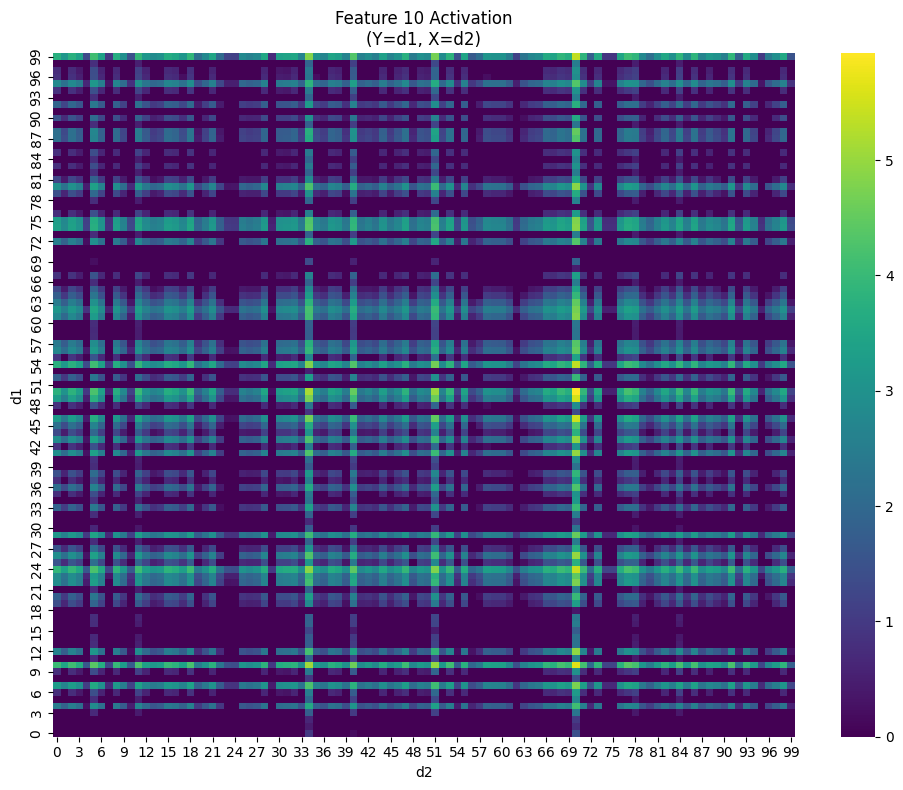

  Row variance (d1 selectivity): 0.4027
  Col variance (d2 selectivity): 1.0493
  → Feature responds more to: d1

Feature 84:


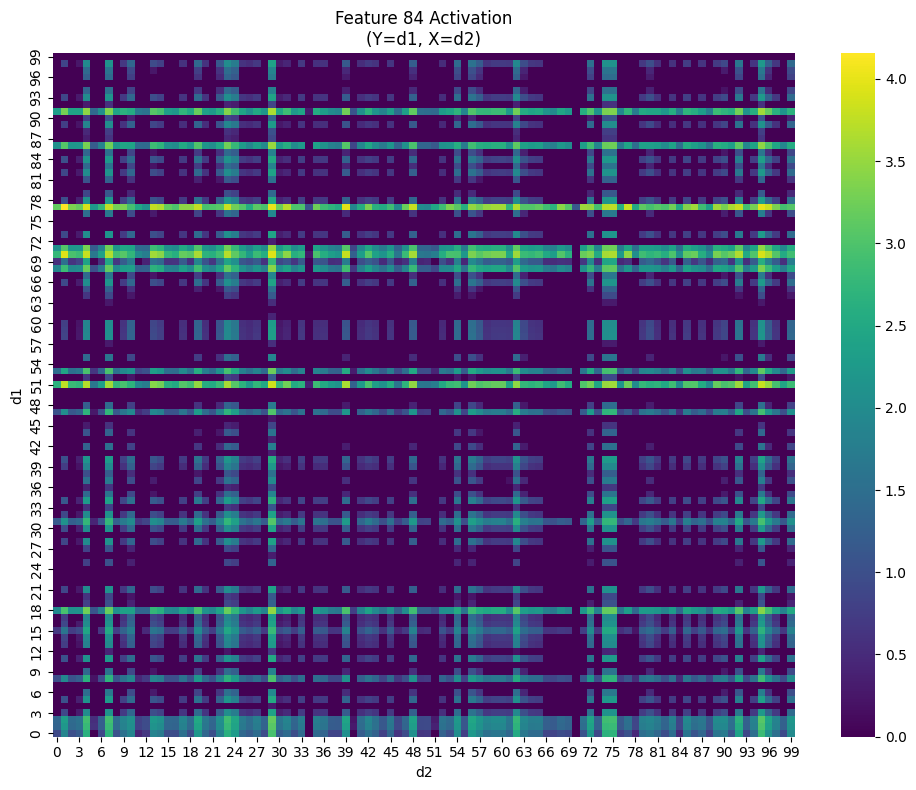

  Row variance (d1 selectivity): 0.2274
  Col variance (d2 selectivity): 0.6066
  → Feature responds more to: d1

Feature 25:


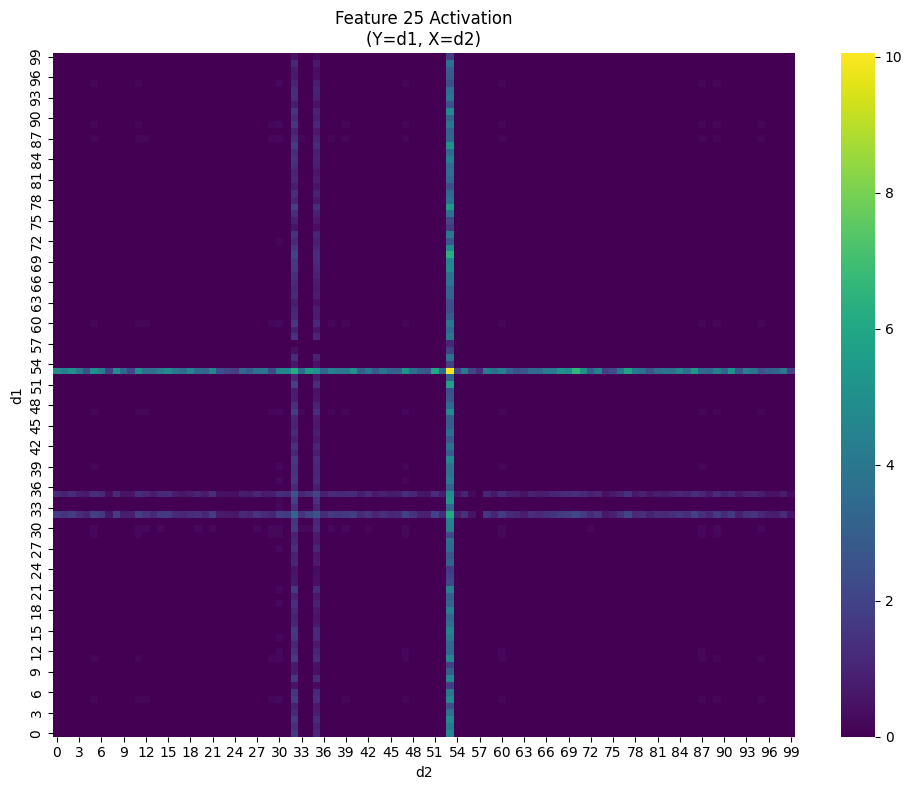

  Row variance (d1 selectivity): 0.1697
  Col variance (d2 selectivity): 0.1900
  → Feature responds more to: d1


In [ ]:
def plot_feature_heatmap(feature_idx, title_suffix=""):
    """Plot feature activation as heatmap over (d1, d2) grid."""
    acts = sae_acts_all[:, feature_idx].numpy()
    
    if acts.max() == 0:
        print(f"Feature {feature_idx} is dead.")
        return
    
    df = pd.DataFrame({
        'd1': d1_all.numpy(),
        'd2': d2_all.numpy(),
        'activation': acts
    })
    
    pivot = df.pivot_table(index='d1', columns='d2', values='activation', aggfunc='mean')
    
    fig, ax = plt.subplots(1, 1, figsize=(10, 8))
    sns.heatmap(pivot, cmap="viridis", ax=ax)
    ax.invert_yaxis()
    ax.set_title(f"Feature {feature_idx} Activation{title_suffix}\n(Y=d1, X=d2)")
    ax.set_xlabel("d2")
    ax.set_ylabel("d1")
    plt.tight_layout()
    if SAVE_DIR is not None:
        os.makedirs(SAVE_DIR, exist_ok=True)
        plt.savefig(os.path.join(SAVE_DIR, f"feature_{feature_idx}_heatmap.png"), dpi=150)
    plt.show()
    
    # Analyze pattern
    # Vertical stripes = responds to d1, Horizontal stripes = responds to d2
    row_var = pivot.var(axis=1).mean()  # Variance across d2 for each d1
    col_var = pivot.var(axis=0).mean()  # Variance across d1 for each d2
    
    print(f"  Row variance (d1 selectivity): {row_var:.4f}")
    print(f"  Col variance (d2 selectivity): {col_var:.4f}")
    print(f"  → Feature responds more to: {'d1' if row_var < col_var else 'd2'}")

# Plot top 3 most frequent features
print("\n" + "=" * 60)
print("FEATURE HEATMAPS (Top 3 by Firing Rate)")
print("=" * 60)

for idx in top_indices[:3]:
    print(f"\nFeature {idx.item()}:")
    plot_feature_heatmap(idx.item())

 ## 9. Visualization: Activation vs Attention Scatter

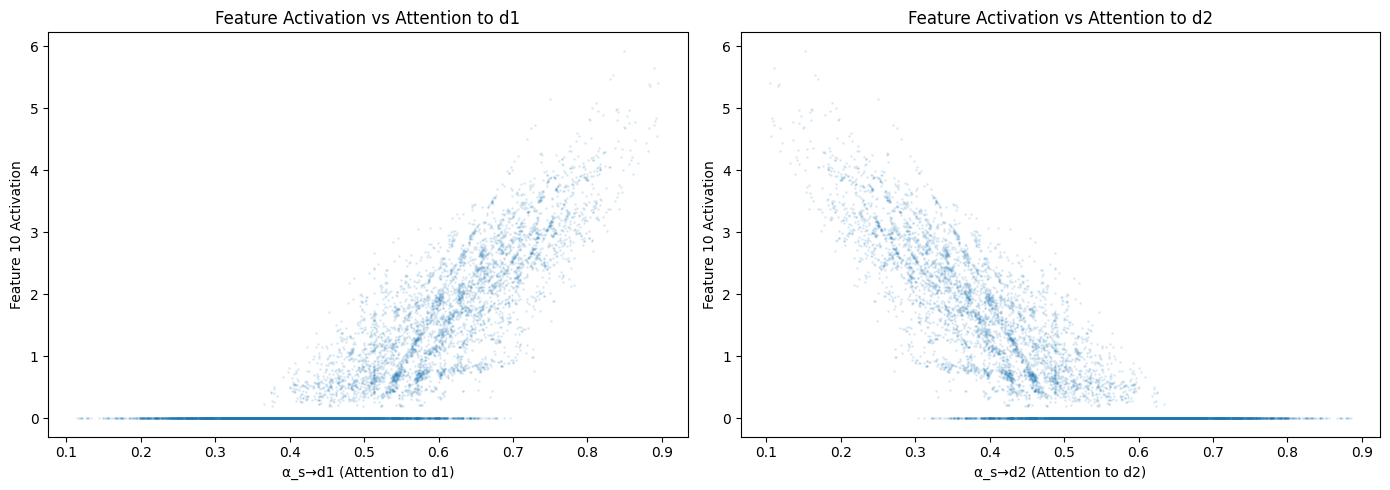

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Pick a highly aligned feature
best_feat_idx = top_indices[0].item()
feat_acts = sae_acts_all[:, best_feat_idx].numpy()

# Scatter: activation vs alpha_d1
axes[0].scatter(alpha_d1_all.numpy(), feat_acts, alpha=0.1, s=1)
axes[0].set_xlabel("α_s→d1 (Attention to d1)")
axes[0].set_ylabel(f"Feature {best_feat_idx} Activation")
axes[0].set_title(f"Feature Activation vs Attention to d1")

# Scatter: activation vs alpha_d2
axes[1].scatter(alpha_d2_all.numpy(), feat_acts, alpha=0.1, s=1)
axes[1].set_xlabel("α_s→d2 (Attention to d2)")
axes[1].set_ylabel(f"Feature {best_feat_idx} Activation")
axes[1].set_title(f"Feature Activation vs Attention to d2")

plt.tight_layout()
if SAVE_DIR is not None:
    os.makedirs(SAVE_DIR, exist_ok=True)
    plt.savefig(os.path.join(SAVE_DIR, "activation_vs_attention.png"), dpi=150)
plt.show()